In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [9]:
image = cv2.imread('flowers.jpg', 0)

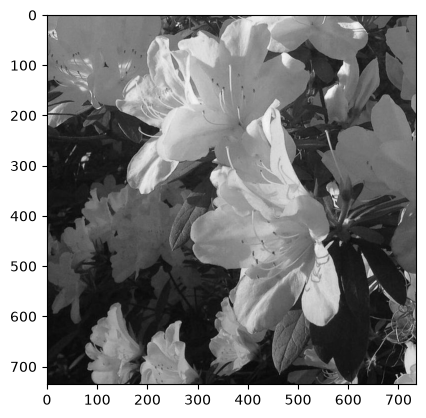

In [10]:
plt.imshow(image, cmap='gray')

In [12]:
histSize = 256
histRange = (0, 256)
accumulate = False

one_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)


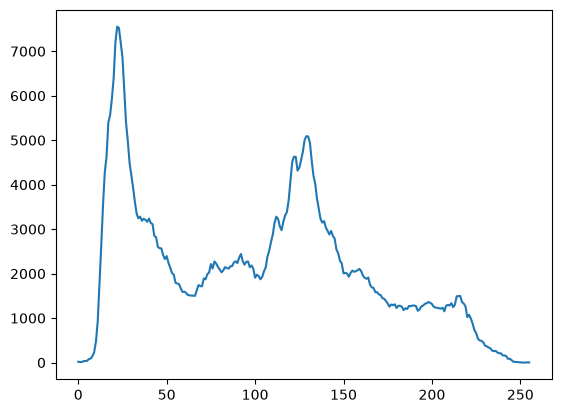

In [13]:
plt.plot(one_hist)

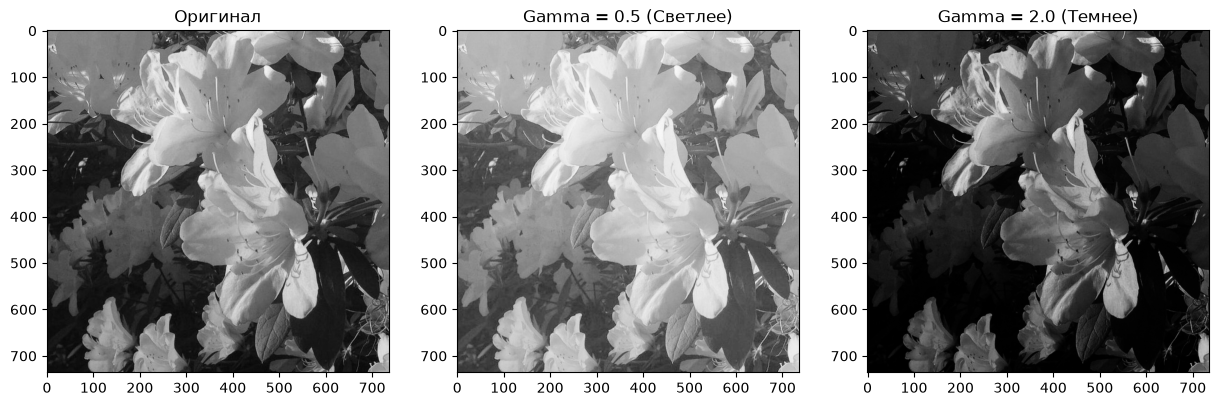

In [15]:
def adjust_gamma(image, gamma=1.0):
    table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

gamma_light = adjust_gamma(image, gamma=0.5) 
gamma_dark = adjust_gamma(image, gamma=2.0)  

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Оригинал')
plt.subplot(1, 3, 2), plt.imshow(gamma_light, cmap='gray'), plt.title('Gamma = 0.5 (Светлее)')
plt.subplot(1, 3, 3), plt.imshow(gamma_dark, cmap='gray'), plt.title('Gamma = 2.0 (Темнее)')
plt.show()

Сравнение с Gamma=0.5: MSE = 2676.81, SSIM = 0.8074
Сравнение с Gamma=2.0: MSE = 2488.88, SSIM = 0.5864


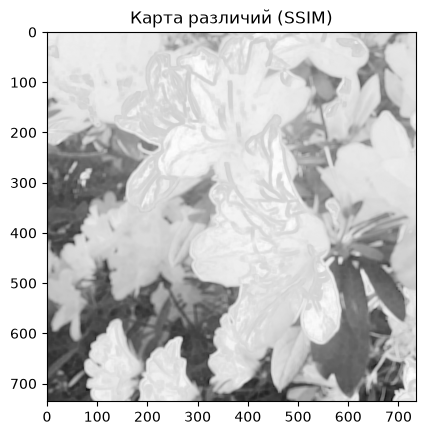

In [16]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

mse_light = mse(image, gamma_light)
ssim_light = ssim(image, gamma_light)

mse_dark = mse(image, gamma_dark)
ssim_dark = ssim(image, gamma_dark)

print(f"Сравнение с Gamma=0.5: MSE = {mse_light:.2f}, SSIM = {ssim_light:.4f}")
print(f"Сравнение с Gamma=2.0: MSE = {mse_dark:.2f}, SSIM = {ssim_dark:.4f}")

from skimage.metrics import structural_similarity
(score, diff) = structural_similarity(image, gamma_light, full=True)
diff = (diff * 255).astype("uint8")
plt.imshow(diff, cmap='gray')
plt.title('Карта различий (SSIM)')
plt.show()

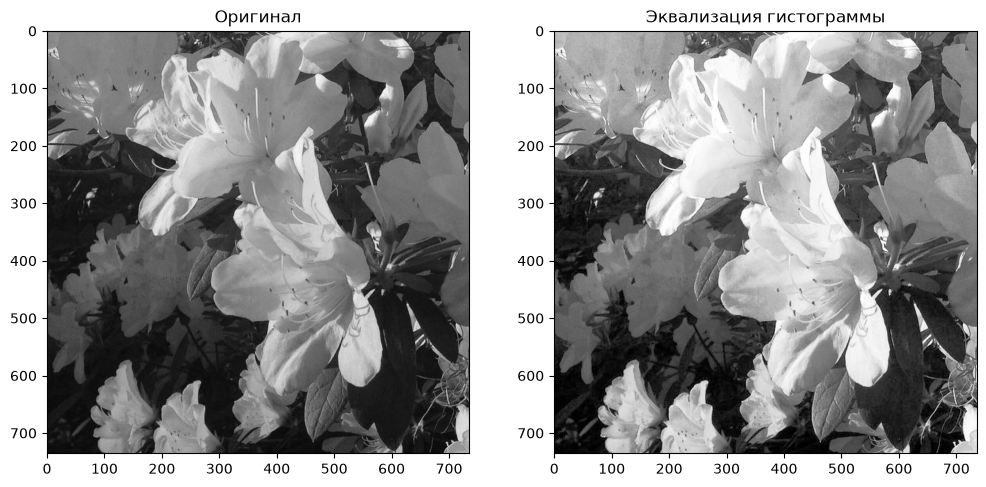

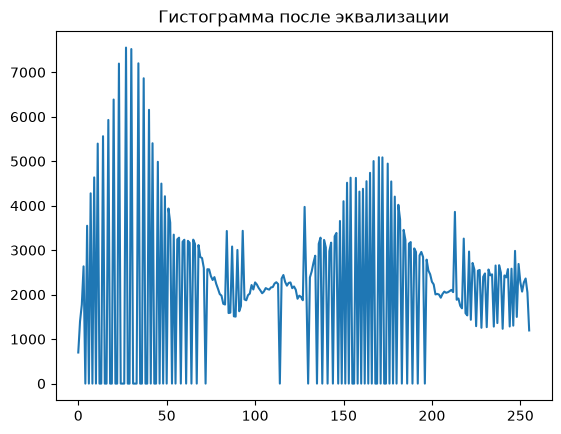

In [17]:
eq_gray = cv2.equalizeHist(image)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Оригинал')
plt.subplot(1, 2, 2), plt.imshow(eq_gray, cmap='gray'), plt.title('Эквализация гистограммы')
plt.show()

eq_hist = cv2.calcHist([eq_gray], [0], None, [256], [0, 256])
plt.plot(eq_hist)
plt.title('Гистограмма после эквализации')
plt.show()

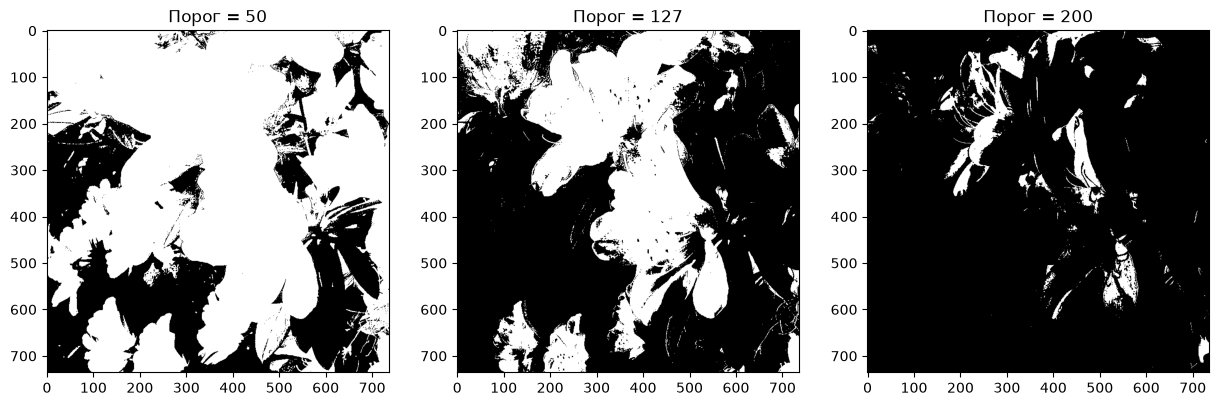

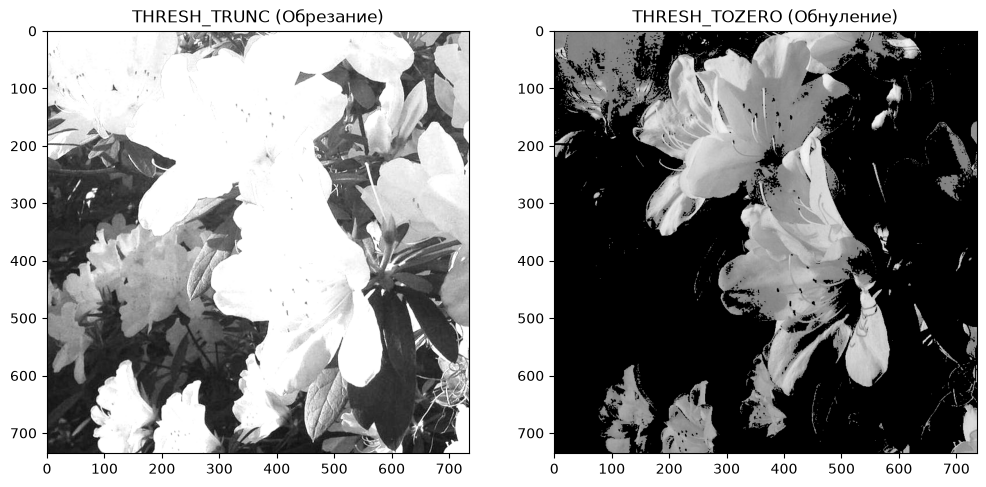

In [18]:
ret, thresh_50 = cv2.threshold(image, 50, 255, cv2.THRESH_BINARY)
ret, thresh_127 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
ret, thresh_200 = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(thresh_50, cmap='gray'), plt.title('Порог = 50')
plt.subplot(1, 3, 2), plt.imshow(thresh_127, cmap='gray'), plt.title('Порог = 127')
plt.subplot(1, 3, 3), plt.imshow(thresh_200, cmap='gray'), plt.title('Порог = 200')
plt.show()

ret, thresh_trunc = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
ret, thresh_tozero = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(thresh_trunc, cmap='gray'), plt.title('THRESH_TRUNC (Обрезание)')
plt.subplot(1, 2, 2), plt.imshow(thresh_tozero, cmap='gray'), plt.title('THRESH_TOZERO (Обнуление)')
plt.show()